# 1.数据读取及特征工程

In [2]:
# 数据读取代码
import pandas as pd
from datetime import datetime

# 读取气象数据
df_weather = pd.read_excel("D:\\工作\\特变电工\\13项目\\电价预测\\数据源\\open-meteo-40.11N113.32E1049m.xlsx",skiprows=12, header=0)
df_weather=df_weather.drop(df_weather.columns[[5,6]],axis=1)
# 处理时间列
df_weather['datetime'] = pd.to_datetime(df_weather['time'])
# 定义地区location_id 对应的权重
weights = {
    0: 0.1,
    1: 0.1,
    2: 0.1,
    3: 0.1,
    4: 0.1,
    5: 0.1,
    6: 0.1,
    7: 0.1,
    8: 0.1,
    9: 0.1
}
df_weather['权重']=df_weather["location_id"].map(weights)
df_weather["加权温度数据(°C)"] = df_weather["temperature_2m (°C)"] * df_weather['权重']
df_weather["加权100米风速数据（m/s）"] = df_weather["wind_speed_100m (m/s)"] * df_weather['权重']
df_weather["加权辐照度（W/m²）"] = df_weather["shortwave_radiation (W/m²)"] * df_weather['权重']

df_weather_groupedbyDate=df_weather.groupby('datetime')[["加权温度数据(°C)","加权100米风速数据（m/s）","加权辐照度（W/m²）"]].sum()
# df_weather_groupedbyDate = df_weather_groupedbyDate[df_weather_groupedbyDate.index >= '2022-01-01']
# df_weather_groupedbyDate

In [3]:
# 将1小时分辨率气象数据转换为15min
df_weather_groupedbyDate_resampled=df_weather_groupedbyDate.resample('15T').mean().interpolate(method='linear')  # 将数据重采样到15分钟,线性插值填补缺失值 
# df_weather_groupedbyDate_resampled

In [4]:
# 读取供需数据
df_DS = pd.read_excel("D:\\工作\\特变电工\\13项目\\电价预测\\数据源\\公有数据-供需数据-日前（2022-01-01至2024-12-31）.xlsx", header=0)

In [5]:
# 读取电价数据
df_Price = pd.read_excel("D:\\工作\\特变电工\\13项目\\电价预测\\数据源\\公有数据-出清量价（2022-01-01至2024-12-31）.xlsx",header=0)

In [6]:
df_DS
# 将 '日期' 和 '时间' 列合并为 datetime 并设为索引
df_DS['时间'] = df_DS['时间'].replace('24:00', '00:00')
df_DS['datetime'] = pd.to_datetime(df_DS['日期'] + ' ' + df_DS['时间'])
df_DS = df_DS.set_index('datetime')

# 删除原 '日期' 和 '时间' 列（可选）
df_DS = df_DS.drop(columns=['日期', '时间'])
# df_DS

In [7]:
# df_Price
# 将 '日期' 和 '时间' 列合并为 datetime 并设为索引
df_Price['时间'] = df_Price['时间'].replace('24:00', '00:00')
df_Price['datetime'] = pd.to_datetime(df_Price['日期'] + ' ' + df_Price['时间'])
df_Price = df_Price.set_index('datetime')

# 删除原 '日期' 和 '时间' 列（可选）
df_Price = df_Price.drop(columns=['日期', '时间'])
# df_Price

In [8]:
# 截取共同时间段
start_time = max(df_weather_groupedbyDate.index.min(), df_DS.index.min(), df_Price.index.min())
end_time = min(df_weather_groupedbyDate.index.max(), df_DS.index.max(), df_Price.index.max())

df_weather_groupedbyDate_resampled = df_weather_groupedbyDate_resampled.loc[start_time:end_time]
df_DS = df_DS.loc[start_time:end_time]
df_Price = df_Price.loc[start_time:end_time]


In [9]:
# 合并并列出缺失数据及缺失行
merged_df = df_weather_groupedbyDate_resampled.merge(df_DS, on='datetime', how='outer').merge(df_Price, on='datetime', how='outer')
print(merged_df.isnull().sum())
missing_rows = merged_df[merged_df.isnull().any(axis=1)]
print(f"------------------------------------缺失行-----------------------------------------------------------------\n{missing_rows.head()}")
# 清洗数据
cleaned_merged_df= merged_df.dropna()
cleaned_merged_df

加权温度数据(°C)              0
加权100米风速数据（m/s）         0
加权辐照度（W/m²）             0
竞价空间-日前\n（MW）          96
省调负荷-日前\n（MW）          96
联络线计划-日前\n（MW）         96
新能源出力-日前\n（MW）         96
光伏出力-日前\n（MW）          96
风电出力-日前\n（MW）          96
非市场化机组出力-日前\n（MW）      96
统一出清价格-日前\n（元/MWh）     96
统一出清价格-实时\n（元/MWh）     96
现货出清电量-日前\n（MWh）      192
现货出清电量-实时\n（MWh）       96
dtype: int64
------------------------------------缺失行-----------------------------------------------------------------
                     加权温度数据(°C)  加权100米风速数据（m/s）  加权辐照度（W/m²）  竞价空间-日前\n（MW）  \
datetime                                                                       
2022-01-01 00:15:00     -3.8875          2.68975          0.0            NaN   
2022-01-01 00:30:00     -3.9750          2.67350          0.0            NaN   
2022-01-01 00:45:00     -4.0625          2.65725          0.0            NaN   
2022-01-01 01:00:00     -4.1500          2.64100          0.0            NaN   
2022-01-01 01:15:00     -4.2825       

,加权温度数据(°C),加权100米风速数据（m/s）,加权辐照度（W/m²）,竞价空间-日前\n（MW）,省调负荷-日前\n（MW）,联络线计划-日前\n（MW）,新能源出力-日前\n（MW）,光伏出力-日前\n（MW）,风电出力-日前\n（MW）,非市场化机组出力-日前\n（MW）,统一出清价格-日前\n（元/MWh）,统一出清价格-实时\n（元/MWh）,现货出清电量-日前\n（MWh）,现货出清电量-实时\n（MWh）
datetime,,,,,,,,,,,,,,
2022-01-01 00:00:00,-3.8000,2.70600,0.0,29551.10,28894.50,-4626.0,3969.40,1.1,3968.30,6953.0,340.0,376.00,2066.00,0.00
2022-01-02 00:00:00,-5.4600,2.20100,0.0,25314.33,29325.50,-5610.0,9621.17,1.6,9619.57,7118.0,0.0,2.00,3246.00,0.00
2022-01-02 00:15:00,-5.6875,2.14925,0.0,32217.60,29085.70,-5610.0,2478.10,0.0,2478.10,6938.0,368.0,370.00,6661.00,934.05
2022-01-02 00:30:00,-5.9150,2.09750,0.0,32157.26,28936.90,-5610.0,2389.64,0.0,2389.64,6887.0,362.0,389.00,6021.00,892.92
2022-01-02 00:45:00,-6.1425,2.04575,0.0,32120.49,28822.00,-5610.0,2311.51,0.0,2311.51,6893.0,365.0,392.13,6308.00,983.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:00:00,-2.8700,2.27800,0.0,36318.48,34927.07,-6784.5,5393.09,0.0,5393.09,1137.0,360.0,335.00,9813.50,9679.55
2024-12-31 22:15:00,-3.0300,2.21325,0.0,36335.12,34813.73,-7015.1,5493.71,0.0,5493.71,1137.0,350.0,340.00,9700.50,9714.28
2024-12-31 22:30:00,-3.1900,2.14850,0.0,35378.85,34179.26,-6755.7,5556.11,0.0,5556.11,1134.0,335.0,340.00,9466.25,9540.37


In [10]:
#  时间索引检查与修复，确保时间索引没有重复、空值、错误类型
cleaned_merged_df.index = pd.to_datetime(cleaned_merged_df.index)
cleaned_merged_df = cleaned_merged_df.sort_index()
assert cleaned_merged_df.index.is_monotonic_increasing
cleaned_merged_df.columns

Index(['加权温度数据(°C)', '加权100米风速数据（m/s）', '加权辐照度（W/m²）', '竞价空间-日前\n（MW）',
       '省调负荷-日前\n（MW）', '联络线计划-日前\n（MW）', '新能源出力-日前\n（MW）', '光伏出力-日前\n（MW）',
       '风电出力-日前\n（MW）', '非市场化机组出力-日前\n（MW）', '统一出清价格-日前\n（元/MWh）',
       '统一出清价格-实时\n（元/MWh）', '现货出清电量-日前\n（MWh）', '现货出清电量-实时\n（MWh）'],
      dtype='object')

In [11]:
# 【电价滞后特征】先把目标电价列赋给一个变量方便操作，增加滞后特征
price_col = '统一出清价格-日前\n（元/MWh）'

# 创建滞后特征，lag 1小时，2小时，3小时（对应4, 8, 12个时间步长）
cleaned_merged_df[f'{price_col}_lag_1h'] = cleaned_merged_df[price_col].shift(4)
cleaned_merged_df[f'{price_col}_lag_2h'] = cleaned_merged_df[price_col].shift(8)
cleaned_merged_df[f'{price_col}_lag_3h'] = cleaned_merged_df[price_col].shift(12)

In [12]:
# 【周期特征、星期特征、节假日特征】

# 假设df里有一列‘weekday’，表示星期几（0-6）
cleaned_merged_df['weekday'] = cleaned_merged_df.index.weekday
cleaned_merged_df = pd.get_dummies(cleaned_merged_df, columns=['weekday'], prefix='wd') # 星期几独热编码
cleaned_merged_df['weekofyear'] = cleaned_merged_df.index.isocalendar().week  # 第几周（ISO周数）

# 节假日特征（需用节假日包）
import holidays

# 这里以中国假期为例
cn_holidays = holidays.China()

cleaned_merged_df['is_holiday'] = cleaned_merged_df.index.to_series().apply(lambda x: 1 if x in cn_holidays else 0)





In [24]:
cleaned_merged_df = cleaned_merged_df.dropna()
cleaned_merged_df

,加权温度数据(°C),加权100米风速数据（m/s）,加权辐照度（W/m²）,竞价空间-日前\n（MW）,省调负荷-日前\n（MW）,联络线计划-日前\n（MW）,新能源出力-日前\n（MW）,光伏出力-日前\n（MW）,风电出力-日前\n（MW）,非市场化机组出力-日前\n（MW）,...,统一出清价格-日前\n（元/MWh）_lag_3h,wd_0,wd_1,wd_2,wd_3,wd_4,wd_5,wd_6,weekofyear,is_holiday
datetime,,,,,,,,,,,,,,,,,,,,,
2022-01-02 02:45:00,-6.595,1.99425,0.0,31666.75,28052.70,-5610.0,1995.95,0.0,1995.95,7014.0,...,340.00,0,0,0,0,0,0,1,52,0
2022-01-02 03:00:00,-6.570,2.07900,0.0,31637.90,28017.00,-5610.0,1989.10,0.0,1989.10,7026.0,...,0.00,0,0,0,0,0,0,1,52,0
2022-01-02 03:15:00,-6.645,2.08750,0.0,31622.48,27996.30,-5610.0,1983.82,0.0,1983.82,7084.0,...,368.00,0,0,0,0,0,0,1,52,0
2022-01-02 03:30:00,-6.720,2.09600,0.0,31579.72,27969.90,-5610.0,2000.18,0.0,2000.18,7086.0,...,362.00,0,0,0,0,0,0,1,52,0
2022-01-02 03:45:00,-6.795,2.10450,0.0,31560.86,27982.70,-5610.0,2031.84,0.0,2031.84,7047.0,...,365.00,0,0,0,0,0,0,1,52,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:00:00,-2.870,2.27800,0.0,36318.48,34927.07,-6784.5,5393.09,0.0,5393.09,1137.0,...,365.00,0,1,0,0,0,0,0,1,0
2024-12-31 22:15:00,-3.030,2.21325,0.0,36335.12,34813.73,-7015.1,5493.71,0.0,5493.71,1137.0,...,360.00,0,1,0,0,0,0,0,1,0
2024-12-31 22:30:00,-3.190,2.14850,0.0,35378.85,34179.26,-6755.7,5556.11,0.0,5556.11,1134.0,...,350.00,0,1,0,0,0,0,0,1,0


# 2.相关性分析

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置字体为 SimHei
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

山西20220101-20241231相关性矩阵:
                           加权温度数据(°C)  加权100米风速数据（m/s）  加权辐照度（W/m²）  \
加权温度数据(°C)                   1.000000         0.022232     0.436960   
加权100米风速数据（m/s）              0.022232         1.000000     0.001741   
加权辐照度（W/m²）                  0.436960         0.001741     1.000000   
竞价空间-日前\n（MW）               -0.190661        -0.366328    -0.466184   
省调负荷-日前\n（MW）               -0.423606         0.052666    -0.275129   
联络线计划-日前\n（MW）              -0.011325         0.078724    -0.276072   
新能源出力-日前\n（MW）              -0.018194         0.473034     0.533977   
光伏出力-日前\n（MW）                0.280005        -0.042950     0.904075   
风电出力-日前\n（MW）               -0.271106         0.656623    -0.100114   
非市场化机组出力-日前\n（MW）            0.094050         0.007017     0.028646   
统一出清价格-日前\n（元/MWh）          -0.005648        -0.207493    -0.279494   
统一出清价格-实时\n（元/MWh）          -0.043894        -0.200115    -0.254380   
现货出清电量-日前\n（MWh）            -0.079737         0.006

C:\Users\96498\.conda\envs\myenv\Lib\site-packages\seaborn\utils.py:80: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  fig.canvas.draw()
C:\Users\96498\.conda\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


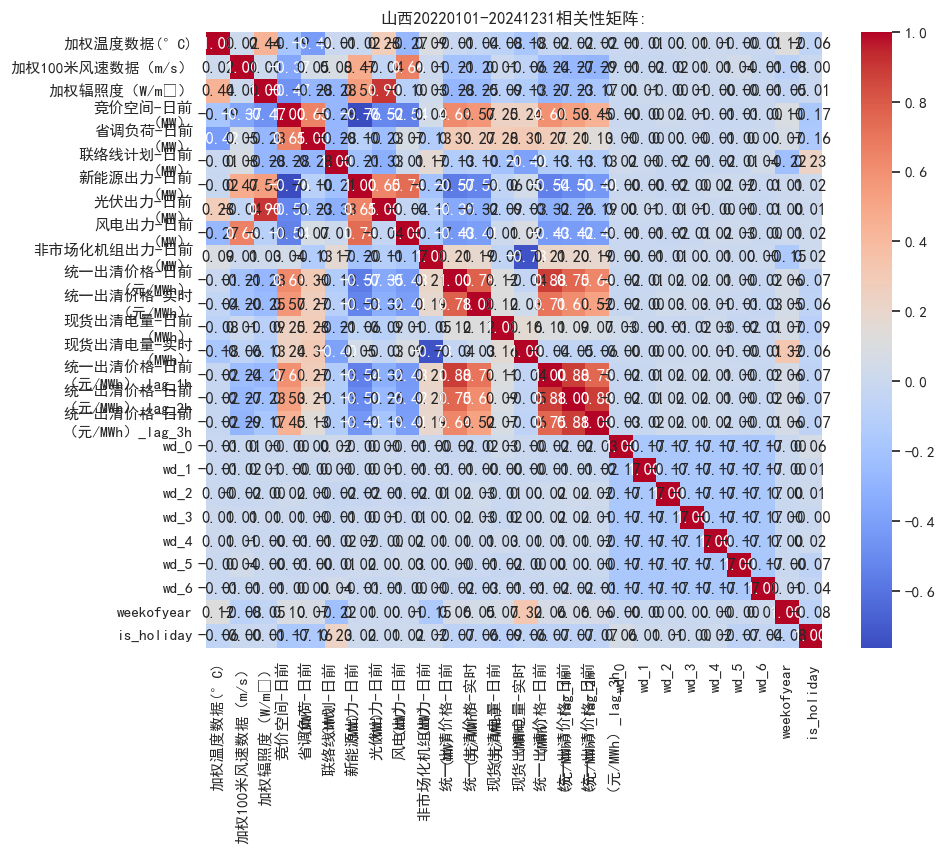

In [14]:
# 计算相关性矩阵
correlation_matrix = cleaned_merged_df.corr()

# 输出相关性矩阵
print("山西20220101-20241231相关性矩阵:")
print(correlation_matrix)

# 可视化相关性矩阵
plt.figure(figsize=(10, 8))
sns.set(font='SimHei')  # 使用 SimHei 字体

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('山西20220101-20241231相关性矩阵:')
plt.show()

# 3.电价预测

In [15]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [30]:
cleaned_merged_df.head(10)

,加权温度数据(°C),加权100米风速数据（m/s）,加权辐照度（W/m²）,竞价空间-日前\n（MW）,省调负荷-日前\n（MW）,联络线计划-日前\n（MW）,新能源出力-日前\n（MW）,光伏出力-日前\n（MW）,风电出力-日前\n（MW）,非市场化机组出力-日前\n（MW）,...,统一出清价格-日前\n（元/MWh）_lag_3h,wd_0,wd_1,wd_2,wd_3,wd_4,wd_5,wd_6,weekofyear,is_holiday
datetime,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,-3.8000,2.70600,0.0,29551.10,28894.5,-4626.0,3969.40,1.1,3968.30,6953.0,...,NaN,0,0,0,0,0,1,0,52,1
2022-01-02 00:00:00,-5.4600,2.20100,0.0,25314.33,29325.5,-5610.0,9621.17,1.6,9619.57,7118.0,...,NaN,0,0,0,0,0,0,1,52,0
2022-01-02 00:15:00,-5.6875,2.14925,0.0,32217.60,29085.7,-5610.0,2478.10,0.0,2478.10,6938.0,...,NaN,0,0,0,0,0,0,1,52,0
2022-01-02 00:30:00,-5.9150,2.09750,0.0,32157.26,28936.9,-5610.0,2389.64,0.0,2389.64,6887.0,...,NaN,0,0,0,0,0,0,1,52,0
2022-01-02 00:45:00,-6.1425,2.04575,0.0,32120.49,28822.0,-5610.0,2311.51,0.0,2311.51,6893.0,...,NaN,0,0,0,0,0,0,1,52,0
2022-01-02 01:00:00,-6.3700,1.99400,0.0,32166.76,28803.9,-5610.0,2247.14,0.0,2247.14,6852.0,...,NaN,0,0,0,0,0,0,1,52,0
2022-01-02 01:15:00,-6.4450,1.93050,0.0,32207.31,28786.4,-5610.0,2189.09,0.0,2189.09,6854.0,...,NaN,0,0,0,0,0,0,1,52,0
2022-01-02 01:30:00,-6.5200,1.86700,0.0,32081.32,28605.6,-5610.0,2134.28,0.0,2134.28,6928.0,...,NaN,0,0,0,0,0,0,1,52,0
2022-01-02 01:45:00,-6.5950,1.80350,0.0,32004.68,28480.4,-5610.0,2085.72,0.0,2085.72,7023.0,...,NaN,0,0,0,0,0,0,1,52,0


In [17]:
# 目标 & 特征列
target_col = '统一出清价格-日前\n（元/MWh）'

feature_cols = [
    '加权温度数据(°C)', '加权100米风速数据（m/s）', '加权辐照度（W/m²）',
    '竞价空间-日前\n（MW）', '省调负荷-日前\n（MW）', '联络线计划-日前\n（MW）',
    '新能源出力-日前\n（MW）', '光伏出力-日前\n（MW）', '风电出力-日前\n（MW）',
    '非市场化机组出力-日前\n（MW）', '现货出清电量-日前\n（MWh）',
    f'{price_col}_lag_1h', f'{price_col}_lag_2h', f'{price_col}_lag_3h', 'wd_0', 'wd_1', 'wd_2', 'wd_3', 'wd_4', 'wd_5', 'wd_6',
    'is_holiday'
]

# 构造 X 和 y
X = cleaned_merged_df[feature_cols]
y = cleaned_merged_df[target_col]
# 去除缺失
X = X.fillna(method='ffill').dropna()
y = y.loc[X.index]


In [27]:
# 拆分训练测试（按时间也可以）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 模型训练
model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.15, max_depth=5)
model.fit(X_train, y_train)

# 预测
y_pred = model.predict(X_test)

# 平均绝对误差（单位和电价相同） 和 均方根误差
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
# “相对误差”或者“准确率”
mae_relative = 1 - mae / y_test.mean()
rmse_relative = 1 - rmse / y_test.mean()

# 评估
print("MAE:", mae_relative)
print("RMSE:", rmse_relative)

MAE: 0.8844384584277168
RMSE: 0.7694202488339039


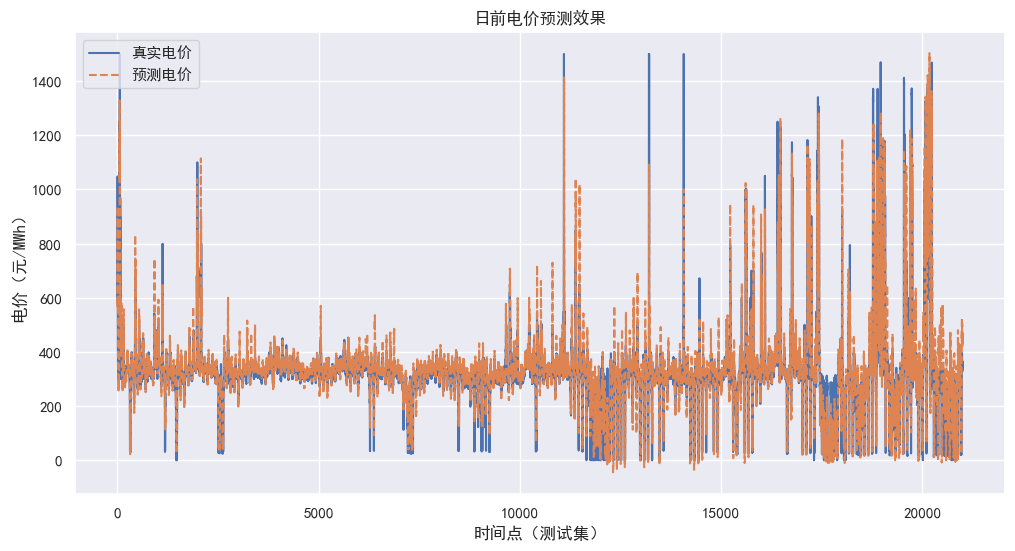

In [28]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows常用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='真实电价')
plt.plot(y_pred, label='预测电价', linestyle='--')
plt.title('日前电价预测效果')
plt.xlabel('时间点（测试集）')
plt.ylabel('电价（元/MWh）')
plt.legend()
plt.grid(True)
plt.show()